# Single Feature Linear Regression using Gradient Descent
Question: Given depth  how well can i predict temperature  using **linear regression** via **gradient descent**?

Note: Of course temp isn't only a factor of depth, since it also depends on seasons significantly, as well as longitude somewhat. A multivariable gradient descent will of course be more accurate, however I'm beginning with a single variable and will later move on to more advanced models.
   

In [1]:
import math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading and Visualizing Dataset

In [30]:
raw = pd.read_csv("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south", sep=r"\s+", header=None).values  # [nz*nx*nt, 6]
depth_all = raw[:, 1]    # every depth value, flat
temp_all  = raw[:, 2]    # every temperature value, flat

KeyboardInterrupt: 

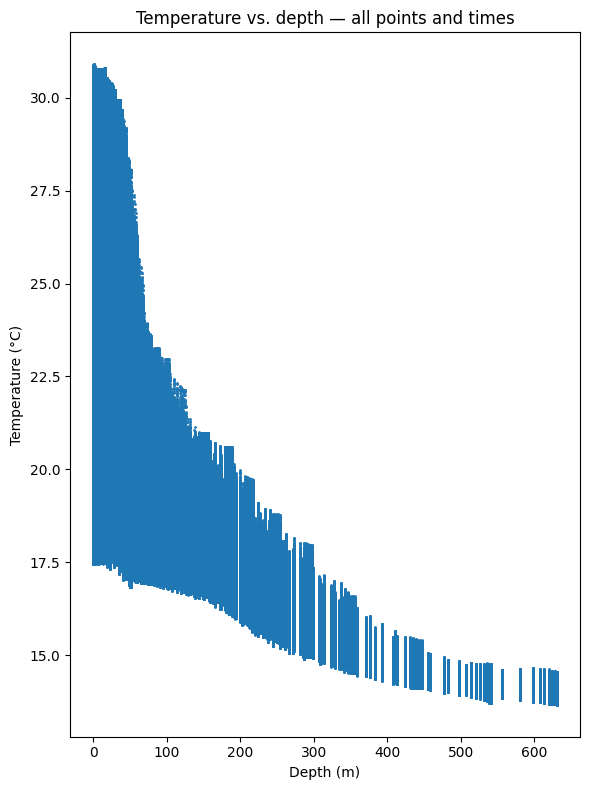

In [32]:
plt.figure(figsize=(6, 8))
plt.scatter(depth_all,temp_all, s=1)   # small, transparent points
plt.xlabel("Depth (m)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs. depth — all points and times")
plt.tight_layout()
plt.show()

# Find Paramaters of linear regression using functions from cousera ML course





## The dataset
| Depth (m)     | Temp (°C) |
| ----------------| ------------------------ |
| x               | y                      |


In [4]:
n = 5000
idx = np.linspace(0, len(depth_all) - 1, n, dtype=int)

x_train = depth_all[idx]   # features
y_train = temp_all[idx]    # target value

## The cost function

The equation for cost with one variable is:
  $$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{1}$$ 
 
where 
  $$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{2}$$
  
- $f_{w,b}(x^{(i)})$ is our prediction for example $i$ using parameters $w,b$.  
- $(f_{w,b}(x^{(i)}) -y^{(i)})^2$ is the squared difference between the target value and the prediction.   
- These differences are summed over all the $m$ examples and divided by `2m` to produce the cost, $J(w,b)$.  

In [5]:
#Function to calculate the cost
def compute_cost(x, y, w, b):
   
    m = x.shape[0] 
    cost = 0
    
    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i])**2
    total_cost = 1 / (2 * m) * cost

    return total_cost

minimum cost = 6.610494 at w = -0.030151


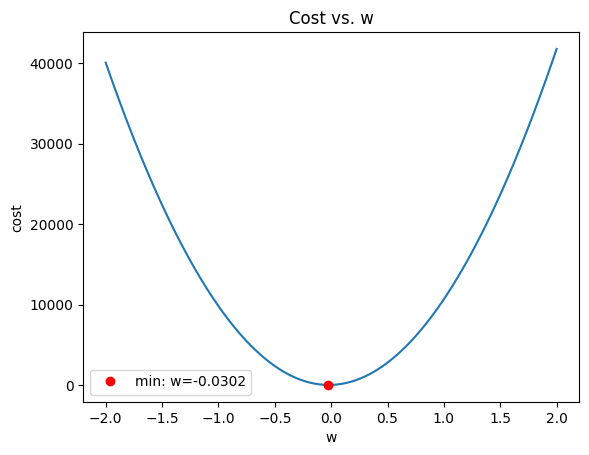

In [33]:
b_fixed = 22.5

w_range = np.linspace(-2, 2, 200)
costs = np.array([compute_cost(x_train, y_train, w, b_fixed) for w in w_range])

# find the minimum
min_idx = np.argmin(costs)
w_min = w_range[min_idx]
cost_min = costs[min_idx]

print(f"minimum cost = {cost_min:.6f} at w = {w_min:.6f}")

plt.plot(w_range, costs)
plt.plot(w_min, cost_min, 'ro', label=f"min: w={w_min:.4f}")
plt.xlabel("w")
plt.ylabel("cost")
plt.title("Cost vs. w")
plt.legend()
plt.show()

## Calculating the gradient
The linear model  predicts $f_{w,b}(x^{(i)})$:
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$
In linear regression, you utilize input training data to fit the parameters $w$,$b$ by minimizing a measure of the error between our predictions $f_{w,b}(x^{(i)})$ and the actual data $y^{(i)}$. The measure is called the $cost$, $J(w,b)$. In training you measure the cost over all of our training samples $x^{(i)},y^{(i)}$
$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2\tag{2}$$ 
In lecture, *gradient descent* was described as:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  
The gradient is defined as:
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

Here *simultaniously* means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

In [6]:
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b 
        dj_dw_i = (f_wb - y[i]) * x[i] 
        dj_db_i = f_wb - y[i] 
        dj_db += dj_db_i
        dj_dw += dj_dw_i 
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db

def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 
    return w, b, J_history, p_history #return w and J,w history for graphing

## Run gradient descent functions and find the model parameters

In [34]:
# initialize parameters
w_init = -0.5
b_init = 22.5
# some gradient descent settings
iterations = 1000
tmp_alpha = 1.0e-5
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")



Iteration    0: Cost 1.49e+03  dj_dw: -9.803e+03, dj_db: -3.821e+01   w: -4.020e-01, b: 2.25004e+01
Iteration  100: Cost 5.72e+00  dj_dw:  1.118e-03, dj_db: -2.893e-01   w: -2.086e-02, b: 2.25021e+01
Iteration  200: Cost 5.72e+00  dj_dw:  1.118e-03, dj_db: -2.891e-01   w: -2.086e-02, b: 2.25024e+01
Iteration  300: Cost 5.72e+00  dj_dw:  1.117e-03, dj_db: -2.889e-01   w: -2.086e-02, b: 2.25027e+01
Iteration  400: Cost 5.72e+00  dj_dw:  1.117e-03, dj_db: -2.887e-01   w: -2.086e-02, b: 2.25030e+01
Iteration  500: Cost 5.72e+00  dj_dw:  1.116e-03, dj_db: -2.885e-01   w: -2.086e-02, b: 2.25033e+01
Iteration  600: Cost 5.72e+00  dj_dw:  1.115e-03, dj_db: -2.883e-01   w: -2.086e-02, b: 2.25036e+01
Iteration  700: Cost 5.72e+00  dj_dw:  1.114e-03, dj_db: -2.881e-01   w: -2.086e-02, b: 2.25039e+01
Iteration  800: Cost 5.72e+00  dj_dw:  1.114e-03, dj_db: -2.879e-01   w: -2.086e-02, b: 2.25042e+01
Iteration  900: Cost 5.72e+00  dj_dw:  1.113e-03, dj_db: -2.877e-01   w: -2.086e-02, b: 2.25045e+01


## Visualize Results

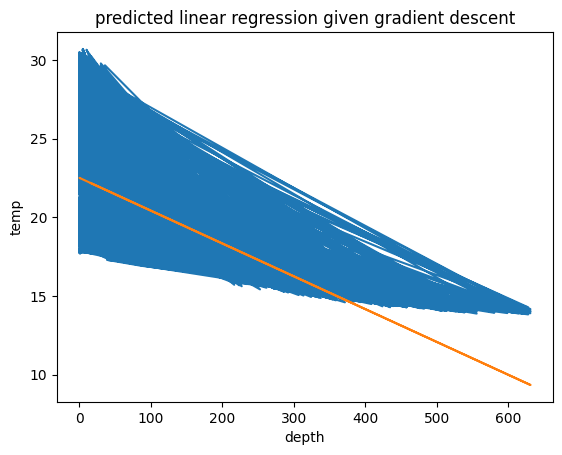

In [37]:
y_hat= w_final * x_train + b_final
plt.plot(x_train,y_train)
plt.plot(x_train, y_hat)
plt.xlabel("depth")
plt.ylabel("temp")
plt.title("predicted linear regression given gradient descent")
plt.show()



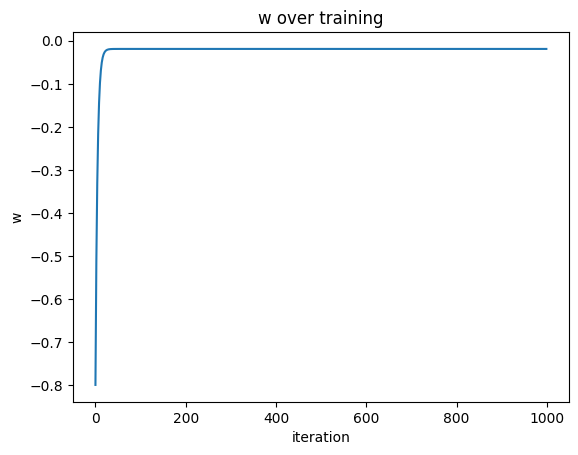

In [36]:
p_history = np.array(p_history, dtype=float)   # converts np.float64 entries cleanly
w_history = p_history[:, 0]
b_history = p_history[:, 1]

plt.plot(w_history)
plt.xlabel("iteration")
plt.ylabel("w")
plt.title("w over training")
plt.show()

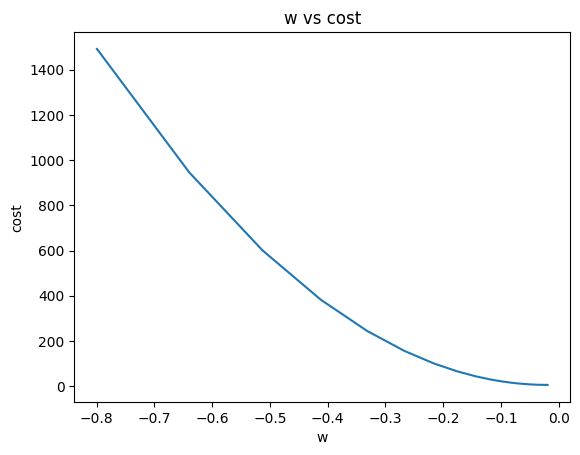

In [39]:
plt.plot(w_history, J_hist)
plt.xlabel("w")
plt.ylabel("cost")
plt.title("w vs cost")
plt.show()

Follow up questions: 
1) How can i choose w and b to get best and most efficient possible results?
2) How can i make the model faster and more efficient (too long on the whole dataset?
3) How to set learning curve here
4) how to implement more features to get better prediction and use gradient descent for nonlinear model